<a href="https://colab.research.google.com/github/MLfinal/Walmart-Recruiting---Store-Sales-Forecasting/blob/dev/models/deep_learning/DLinear/model_experiment_DLinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DLinear experiment v2 — 104w context + series calibration + future calendar

This is the next incremental DLinear experiment.

Previous results on the same 39-week validation split:
- seasonal naive WMAE: `1604.27`
- DLinear baseline, 52w context: `1523.21`
- DLinear v1, 104w + series calibration: `1506.28`

This notebook keeps the v1 setup and adds only known future calendar features:
- `IsHoliday`
- week-of-year sine/cosine
- month sine/cosine
- normalized forecast horizon position

No markdown, economic, store metadata, or target-derived validation leakage features are added yet.

In [2]:
%pip install -q "torch>=2.3,<3" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4"

In [3]:
from __future__ import annotations

import json
import math
import platform
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import wandb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

pd.set_option("display.max_columns", 100)
print({
    "python": platform.python_version(),
    "torch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
})

{'python': '3.12.13', 'torch': '2.11.0+cpu', 'cuda_available': False, 'device_name': 'cpu'}


In [11]:
CONFIG = {
    "seed": SEED,
    "validation_weeks": 39,
    "input_weeks": 65, # Modified from 104 to 65 to resolve ValueError
    "holiday_weight": 5.0,
    "batch_size": 512,
    "epochs": 90,
    "learning_rate": 7e-4,
    "weight_decay": 2e-4,
    "series_bias_weight_decay": 1e-3,
    "calendar_weight_decay": 1e-4,
    "patience": 14,
    "num_workers": 2,
    "clip_grad_norm": 1.0,
    "moving_avg_kernel": 25,
    "use_series_calibration": True,
    "use_future_calendar": True,
    "baseline_dlinear_39w_wmae": 1523.209716796875,
    "dlinear_v1_104w_calibration_wmae": 1506.282470703125,
    "seasonal_naive_wmae_reference": 1604.2697073319134,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "wandb_entity": "kende23-n-a",
    "wandb_group": "dlinear-experiments",
}

DATA_DIR = Path("/content/drive/MyDrive/walmart_competition_data")
OUTPUT_DIR = Path("/content/artifacts/dlinear_experiment_v2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG

{'seed': 42,
 'validation_weeks': 39,
 'input_weeks': 65,
 'holiday_weight': 5.0,
 'batch_size': 512,
 'epochs': 90,
 'learning_rate': 0.0007,
 'weight_decay': 0.0002,
 'series_bias_weight_decay': 0.001,
 'calendar_weight_decay': 0.0001,
 'patience': 14,
 'num_workers': 2,
 'clip_grad_norm': 1.0,
 'moving_avg_kernel': 25,
 'use_series_calibration': True,
 'use_future_calendar': True,
 'baseline_dlinear_39w_wmae': 1523.209716796875,
 'dlinear_v1_104w_calibration_wmae': 1506.282470703125,
 'seasonal_naive_wmae_reference': 1604.2697073319134,
 'device': 'cpu',
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'wandb_entity': 'kende23-n-a',
 'wandb_group': 'dlinear-experiments'}

In [5]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print(f"Not running in Colab or Drive unavailable: {exc}")

Mounted at /content/drive


## Load data and build the weekly panel

In [6]:
train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"])
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])

required_train = {"Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"}
required_test = {"Store", "Dept", "Date", "IsHoliday"}
missing_train = required_train.difference(train_raw.columns)
missing_test = required_test.difference(test_raw.columns)
if missing_train or missing_test:
    raise ValueError({"missing_train": sorted(missing_train), "missing_test": sorted(missing_test)})

train_raw = train_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
test_raw = test_raw.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

all_train_dates = pd.Index(sorted(train_raw["Date"].unique()), name="Date")
test_dates = pd.Index(sorted(test_raw["Date"].unique()), name="Date")
val_dates = all_train_dates[-CONFIG["validation_weeks"]:]
fit_dates = all_train_dates[:-CONFIG["validation_weeks"]]
split_pos = len(fit_dates)

if split_pos < CONFIG["input_weeks"]:
    raise ValueError("input_weeks is longer than available pre-validation history.")

sales_panel = (
    train_raw.pivot_table(index=["Store", "Dept"], columns="Date", values="Weekly_Sales", aggfunc="sum")
    .reindex(columns=all_train_dates)
    .fillna(0.0)
    .sort_index()
)

holiday_by_date = (
    train_raw[["Date", "IsHoliday"]]
    .drop_duplicates("Date")
    .set_index("Date")
    .reindex(all_train_dates)["IsHoliday"]
    .fillna(False)
    .astype(bool)
)

values = sales_panel.to_numpy(dtype=np.float32)
holiday_flags = holiday_by_date.to_numpy(dtype=bool)

print({
    "n_series": len(sales_panel),
    "n_dates": len(all_train_dates),
    "fit_range": (str(fit_dates.min().date()), str(fit_dates.max().date())),
    "validation_range": (str(val_dates.min().date()), str(val_dates.max().date())),
    "test_horizon": len(test_dates),
})

{'n_series': 3331, 'n_dates': 143, 'fit_range': ('2010-02-05', '2012-01-27'), 'validation_range': ('2012-02-03', '2012-10-26'), 'test_horizon': 39}


## Calendar features

These are known before prediction time, so they are safe for validation and test inference.

In [7]:
def make_calendar_features(dates: pd.Index, holiday_flags_for_dates: np.ndarray) -> np.ndarray:
    dates = pd.DatetimeIndex(dates)
    week = dates.isocalendar().week.astype(float).to_numpy()
    month = dates.month.astype(float).to_numpy()
    horizon_position = np.linspace(0.0, 1.0, len(dates), dtype=np.float32)
    features = np.column_stack([
        np.asarray(holiday_flags_for_dates, dtype=np.float32),
        np.sin(2.0 * np.pi * week / 52.0),
        np.cos(2.0 * np.pi * week / 52.0),
        np.sin(2.0 * np.pi * month / 12.0),
        np.cos(2.0 * np.pi * month / 12.0),
        horizon_position,
    ]).astype(np.float32)
    return features


calendar_features = make_calendar_features(all_train_dates, holiday_flags)
calendar_feature_names = ["is_holiday", "week_sin", "week_cos", "month_sin", "month_cos", "horizon_position"]
calendar_dim = calendar_features.shape[1]
print({"calendar_dim": calendar_dim, "calendar_feature_names": calendar_feature_names})

{'calendar_dim': 6, 'calendar_feature_names': ['is_holiday', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'horizon_position']}


## Metric, datasets, and model

In [8]:
def wmae(y_true: np.ndarray, y_pred: np.ndarray, is_holiday: np.ndarray, holiday_weight: float = 5.0) -> float:
    weights = np.where(np.asarray(is_holiday, dtype=bool), holiday_weight, 1.0)
    return float(np.sum(weights * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(weights))


class WindowDataset(Dataset):
    def __init__(self, values: np.ndarray, holiday_flags: np.ndarray, calendar_features: np.ndarray, input_len: int, pred_len: int, end_pos: int):
        self.values = values.astype(np.float32)
        self.holiday_flags = holiday_flags.astype(bool)
        self.calendar_features = calendar_features.astype(np.float32)
        self.input_len = int(input_len)
        self.pred_len = int(pred_len)
        self.end_pos = int(end_pos)
        self.index = []
        max_start = self.end_pos - self.input_len - self.pred_len
        if max_start < 0:
            raise ValueError("Not enough history for configured windows.")
        for series_idx in range(self.values.shape[0]):
            for start in range(max_start + 1):
                self.index.append((series_idx, start))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx: int):
        series_idx, start = self.index[idx]
        x = self.values[series_idx, start:start + self.input_len]
        y = self.values[series_idx, start + self.input_len:start + self.input_len + self.pred_len]
        mean = x.mean(dtype=np.float64).astype(np.float32)
        std = x.std(dtype=np.float64).astype(np.float32)
        std = np.float32(max(float(std), 1.0))
        target_positions = np.arange(start + self.input_len, start + self.input_len + self.pred_len)
        weights = np.where(self.holiday_flags[target_positions], CONFIG["holiday_weight"], 1.0).astype(np.float32)
        return {
            "x": torch.from_numpy(((x - mean) / std)[:, None]),
            "y": torch.from_numpy((y - mean) / std),
            "weights": torch.from_numpy(weights),
            "future_calendar": torch.from_numpy(self.calendar_features[target_positions]),
            "mean": torch.tensor(mean, dtype=torch.float32),
            "std": torch.tensor(std, dtype=torch.float32),
            "series_idx": torch.tensor(series_idx, dtype=torch.long),
        }


class ValidationDataset(Dataset):
    def __init__(self, values: np.ndarray, holiday_flags: np.ndarray, calendar_features: np.ndarray, input_len: int, pred_len: int, split_pos: int):
        self.values = values.astype(np.float32)
        self.holiday_flags = holiday_flags.astype(bool)
        self.calendar_features = calendar_features.astype(np.float32)
        self.input_len = int(input_len)
        self.pred_len = int(pred_len)
        self.split_pos = int(split_pos)

    def __len__(self):
        return self.values.shape[0]

    def __getitem__(self, series_idx: int):
        start = self.split_pos - self.input_len
        x = self.values[series_idx, start:self.split_pos]
        y = self.values[series_idx, self.split_pos:self.split_pos + self.pred_len]
        mean = x.mean(dtype=np.float64).astype(np.float32)
        std = x.std(dtype=np.float64).astype(np.float32)
        std = np.float32(max(float(std), 1.0))
        target_positions = np.arange(self.split_pos, self.split_pos + self.pred_len)
        weights = np.where(self.holiday_flags[target_positions], CONFIG["holiday_weight"], 1.0).astype(np.float32)
        return {
            "x": torch.from_numpy(((x - mean) / std)[:, None]),
            "y": torch.from_numpy((y - mean) / std),
            "weights": torch.from_numpy(weights),
            "future_calendar": torch.from_numpy(self.calendar_features[target_positions]),
            "mean": torch.tensor(mean, dtype=torch.float32),
            "std": torch.tensor(std, dtype=torch.float32),
            "series_idx": torch.tensor(series_idx, dtype=torch.long),
        }

In [9]:
class MovingAverage(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.kernel_size = int(kernel_size)
        self.avg = nn.AvgPool1d(kernel_size=self.kernel_size, stride=1, padding=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        pad_left = (self.kernel_size - 1) // 2
        pad_right = self.kernel_size - 1 - pad_left
        front = x[:, :1, :].repeat(1, pad_left, 1)
        end = x[:, -1:, :].repeat(1, pad_right, 1)
        x_pad = torch.cat([front, x, end], dim=1)
        return self.avg(x_pad.permute(0, 2, 1)).permute(0, 2, 1)


class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size: int):
        super().__init__()
        self.moving_average = MovingAverage(kernel_size)

    def forward(self, x: torch.Tensor):
        trend = self.moving_average(x)
        seasonal = x - trend
        return seasonal, trend


class DLinearCalendar(nn.Module):
    def __init__(self, seq_len: int, pred_len: int, n_series: int, calendar_dim: int, moving_avg_kernel: int = 25, use_series_calibration: bool = True):
        super().__init__()
        self.seq_len = int(seq_len)
        self.pred_len = int(pred_len)
        self.decomposition = SeriesDecomposition(moving_avg_kernel)
        self.linear_seasonal = nn.Linear(self.seq_len, self.pred_len)
        self.linear_trend = nn.Linear(self.seq_len, self.pred_len)
        self.series_bias = nn.Embedding(n_series, self.pred_len) if use_series_calibration else None
        self.calendar_head = nn.Sequential(
            nn.Linear(calendar_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )
        self._init_weights()

    def _init_weights(self):
        nn.init.constant_(self.linear_seasonal.weight, 1.0 / self.seq_len)
        nn.init.constant_(self.linear_trend.weight, 1.0 / self.seq_len)
        nn.init.zeros_(self.linear_seasonal.bias)
        nn.init.zeros_(self.linear_trend.bias)
        if self.series_bias is not None:
            nn.init.zeros_(self.series_bias.weight)
        for module in self.calendar_head.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor, series_idx: torch.Tensor, future_calendar: torch.Tensor) -> torch.Tensor:
        seasonal, trend = self.decomposition(x)
        seasonal = seasonal.permute(0, 2, 1)
        trend = trend.permute(0, 2, 1)
        out = self.linear_seasonal(seasonal) + self.linear_trend(trend)
        out = out.permute(0, 2, 1).squeeze(-1)
        if self.series_bias is not None:
            out = out + self.series_bias(series_idx)
        calendar_adjustment = self.calendar_head(future_calendar).squeeze(-1)
        return out + calendar_adjustment


def weighted_mae_loss(pred: torch.Tensor, target: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
    return (torch.abs(pred - target) * weights).sum() / weights.sum().clamp_min(1.0)

## DataLoaders and benchmark

In [12]:
train_ds = WindowDataset(values, holiday_flags, calendar_features, CONFIG["input_weeks"], CONFIG["validation_weeks"], split_pos)
val_ds = ValidationDataset(values, holiday_flags, calendar_features, CONFIG["input_weeks"], CONFIG["validation_weeks"], split_pos)
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

actual_val = values[:, split_pos:split_pos + CONFIG["validation_weeks"]]
seasonal_naive = values[:, split_pos - 52:split_pos - 52 + CONFIG["validation_weeks"]]
val_holidays_matrix = np.tile(holiday_flags[split_pos:split_pos + CONFIG["validation_weeks"]], (values.shape[0], 1))
seasonal_naive_wmae = wmae(actual_val.ravel(), seasonal_naive.ravel(), val_holidays_matrix.ravel(), CONFIG["holiday_weight"])

print({
    "train_windows": len(train_ds),
    "validation_series": len(val_ds),
    "seasonal_naive_wmae": seasonal_naive_wmae,
})

{'train_windows': 3331, 'validation_series': 3331, 'seasonal_naive_wmae': 1604.2697073319134}


## Train

In [13]:
def evaluate_model(model: nn.Module, loader: DataLoader, device: str):
    model.eval()
    pred_batches, target_batches, weight_batches = [], [], []
    norm_loss_total = 0.0
    norm_weight_total = 0.0
    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(device)
            y = batch["y"].to(device)
            weights = batch["weights"].to(device)
            series_idx = batch["series_idx"].to(device)
            future_calendar = batch["future_calendar"].to(device)
            pred_norm = model(x, series_idx, future_calendar)
            norm_loss_total += float((torch.abs(pred_norm - y) * weights).sum().cpu())
            norm_weight_total += float(weights.sum().cpu())

            mean = batch["mean"].to(device).unsqueeze(1)
            std = batch["std"].to(device).unsqueeze(1)
            pred = (pred_norm * std + mean).clamp_min(0.0)
            target = y * std + mean

            pred_batches.append(pred.cpu().numpy())
            target_batches.append(target.cpu().numpy())
            weight_batches.append(batch["weights"].cpu().numpy())

    preds = np.concatenate(pred_batches, axis=0)
    targets = np.concatenate(target_batches, axis=0)
    weights = np.concatenate(weight_batches, axis=0)
    return {
        "preds": preds,
        "targets": targets,
        "weights": weights,
        "normalized_wmae": norm_loss_total / max(norm_weight_total, 1.0),
        "wmae": float(np.sum(np.abs(preds - targets) * weights) / np.sum(weights)),
    }


run = wandb.init(
    project=CONFIG["wandb_project"],
    entity=CONFIG["wandb_entity"],
    group=CONFIG["wandb_group"],
    job_type="experiment_train",
    name="dlinear_v2_104w_series_calendar",
    config=CONFIG,
)

wandb.config.update({
    "n_series": len(sales_panel),
    "train_windows": len(train_ds),
    "validation_start": str(val_dates.min().date()),
    "validation_end": str(val_dates.max().date()),
    "seasonal_naive_wmae": seasonal_naive_wmae,
    "calendar_feature_names": calendar_feature_names,
}, allow_val_change=True)

device = CONFIG["device"]
model = DLinearCalendar(
    seq_len=CONFIG["input_weeks"],
    pred_len=CONFIG["validation_weeks"],
    n_series=len(sales_panel),
    calendar_dim=calendar_dim,
    moving_avg_kernel=CONFIG["moving_avg_kernel"],
    use_series_calibration=CONFIG["use_series_calibration"],
).to(device)

main_params, series_params, calendar_params = [], [], []
for name, param in model.named_parameters():
    if "series_bias" in name:
        series_params.append(param)
    elif "calendar_head" in name:
        calendar_params.append(param)
    else:
        main_params.append(param)

optimizer = torch.optim.AdamW([
    {"params": main_params, "weight_decay": CONFIG["weight_decay"]},
    {"params": series_params, "weight_decay": CONFIG["series_bias_weight_decay"]},
    {"params": calendar_params, "weight_decay": CONFIG["calendar_weight_decay"]},
], lr=CONFIG["learning_rate"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)

best_wmae = math.inf
best_epoch = -1
best_state = None
epochs_without_improvement = 0

for epoch in range(1, CONFIG["epochs"] + 1):
    model.train()
    train_loss_total = 0.0
    train_weight_total = 0.0
    for batch in train_loader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        weights = batch["weights"].to(device)
        series_idx = batch["series_idx"].to(device)
        future_calendar = batch["future_calendar"].to(device)

        optimizer.zero_grad(set_to_none=True)
        pred = model(x, series_idx, future_calendar)
        loss = weighted_mae_loss(pred, y, weights)
        loss.backward()
        if CONFIG["clip_grad_norm"]:
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["clip_grad_norm"])
        optimizer.step()

        train_loss_total += float((torch.abs(pred.detach() - y) * weights).sum().cpu())
        train_weight_total += float(weights.sum().cpu())

    train_loss = train_loss_total / max(train_weight_total, 1.0)
    val_result = evaluate_model(model, val_loader, device)
    scheduler.step(val_result["wmae"])

    metrics = {
        "epoch": epoch,
        "train/normalized_wmae_loss": train_loss,
        "validation/normalized_wmae_loss": val_result["normalized_wmae"],
        "validation/wmae": val_result["wmae"],
        "validation/improvement_vs_seasonal_naive_pct": 100.0 * (seasonal_naive_wmae - val_result["wmae"]) / seasonal_naive_wmae,
        "validation/improvement_vs_baseline_pct": 100.0 * (CONFIG["baseline_dlinear_39w_wmae"] - val_result["wmae"]) / CONFIG["baseline_dlinear_39w_wmae"],
        "validation/improvement_vs_v1_pct": 100.0 * (CONFIG["dlinear_v1_104w_calibration_wmae"] - val_result["wmae"]) / CONFIG["dlinear_v1_104w_calibration_wmae"],
        "learning_rate": optimizer.param_groups[0]["lr"],
    }
    wandb.log(metrics)
    print(metrics)

    if val_result["wmae"] < best_wmae:
        best_wmae = val_result["wmae"]
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= CONFIG["patience"]:
            print(f"Early stopping at epoch {epoch}; best epoch was {best_epoch}.")
            break

model.load_state_dict(best_state)
best_val_result = evaluate_model(model, val_loader, device)
wandb.summary["best_epoch"] = best_epoch
wandb.summary["best_validation_wmae"] = best_val_result["wmae"]
wandb.summary["seasonal_naive_wmae"] = seasonal_naive_wmae
wandb.summary["baseline_dlinear_39w_wmae"] = CONFIG["baseline_dlinear_39w_wmae"]
wandb.summary["dlinear_v1_104w_calibration_wmae"] = CONFIG["dlinear_v1_104w_calibration_wmae"]
wandb.summary["best_improvement_vs_v1_pct"] = 100.0 * (CONFIG["dlinear_v1_104w_calibration_wmae"] - best_val_result["wmae"]) / CONFIG["dlinear_v1_104w_calibration_wmae"]

print({"best_epoch": best_epoch, "best_validation_wmae": best_val_result["wmae"]})

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'epoch': 1, 'train/normalized_wmae_loss': 2.853233821579517, 'validation/normalized_wmae_loss': 1.1148602101590794, 'validation/wmae': 4186.2734375, 'validation/improvement_vs_seasonal_naive_pct': -160.94573863532327, 'validation/improvement_vs_baseline_pct': -174.83237477654913, 'validation/improvement_vs_v1_pct': -177.92087599252673, 'learning_rate': 0.0007}
{'epoch': 2, 'train/normalized_wmae_loss': 2.7583877878117624, 'validation/normalized_wmae_loss': 1.0644551585045703, 'validation/wmae': 3972.498291015625, 'validation/improvement_vs_seasonal_naive_pct': -147.6203516690688, 'validation/improvement_vs_baseline_pct': -160.7978564743735, 'validation/improvement_vs_v1_pct': -163.7286410935449, 'learning_rate': 0.0007}
{'epoch': 3, 'train/normalized_wmae_loss': 2.6796841198765606, 'validation/normalized_wmae_loss': 1.0173079807793648, 'validation/wmae': 3759.522705078125, 'validation/improvement_vs_seasonal_naive_pct': -134.34480423685412, 'validation/improvement_vs_baseline_pct': -1

## Save artifacts

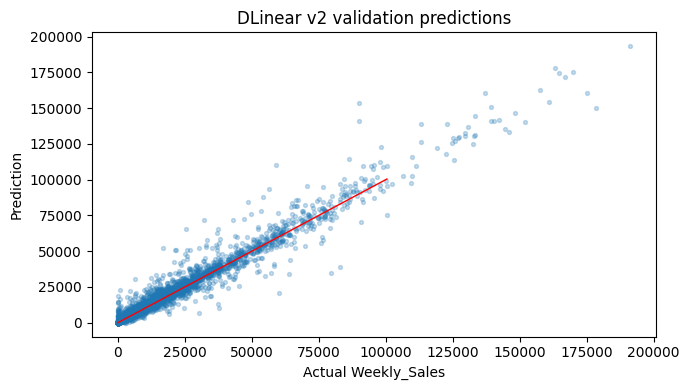

{'experiment': 'dlinear_v2_104w_series_calendar',
 'best_epoch': 36,
 'best_validation_wmae': 1961.4508056640625,
 'baseline_dlinear_39w_wmae': 1523.209716796875,
 'dlinear_v1_104w_calibration_wmae': 1506.282470703125,
 'seasonal_naive_wmae': 1604.2697073319134,
 'improvement_vs_v1_pct': -30.21799322596294,
 'calendar_feature_names': ['is_holiday',
  'week_sin',
  'week_cos',
  'month_sin',
  'month_cos',
  'horizon_position']}

In [14]:
preds = best_val_result["preds"]
targets = best_val_result["targets"]

records = []
for row_idx, (store, dept) in enumerate(sales_panel.index):
    for horizon_idx, date in enumerate(val_dates):
        records.append({
            "Store": int(store),
            "Dept": int(dept),
            "Date": pd.Timestamp(date),
            "IsHoliday": bool(holiday_by_date.loc[date]),
            "Weekly_Sales": float(targets[row_idx, horizon_idx]),
            "Prediction": float(preds[row_idx, horizon_idx]),
            "AbsError": float(abs(targets[row_idx, horizon_idx] - preds[row_idx, horizon_idx])),
        })

val_pred_df = pd.DataFrame(records)
val_pred_path = OUTPUT_DIR / "dlinear_v2_validation_predictions.csv"
val_pred_df.to_csv(val_pred_path, index=False)

checkpoint_path = OUTPUT_DIR / "dlinear_v2_checkpoint.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "config": CONFIG,
    "best_epoch": best_epoch,
    "best_validation_wmae": best_val_result["wmae"],
    "series_index": sales_panel.index.tolist(),
    "train_dates": [str(pd.Timestamp(d).date()) for d in all_train_dates],
    "validation_dates": [str(pd.Timestamp(d).date()) for d in val_dates],
    "calendar_feature_names": calendar_feature_names,
}, checkpoint_path)

summary = {
    "experiment": "dlinear_v2_104w_series_calendar",
    "best_epoch": int(best_epoch),
    "best_validation_wmae": float(best_val_result["wmae"]),
    "baseline_dlinear_39w_wmae": float(CONFIG["baseline_dlinear_39w_wmae"]),
    "dlinear_v1_104w_calibration_wmae": float(CONFIG["dlinear_v1_104w_calibration_wmae"]),
    "seasonal_naive_wmae": float(seasonal_naive_wmae),
    "improvement_vs_v1_pct": float(100.0 * (CONFIG["dlinear_v1_104w_calibration_wmae"] - best_val_result["wmae"]) / CONFIG["dlinear_v1_104w_calibration_wmae"]),
    "calendar_feature_names": calendar_feature_names,
}
summary_path = OUTPUT_DIR / "dlinear_v2_summary.json"
summary_path.write_text(json.dumps(summary, indent=2))

fig, ax = plt.subplots(figsize=(7, 4))
sample = val_pred_df.sample(min(5000, len(val_pred_df)), random_state=SEED)
ax.scatter(sample["Weekly_Sales"], sample["Prediction"], s=8, alpha=0.25)
max_axis = np.nanpercentile(sample[["Weekly_Sales", "Prediction"]].to_numpy(), 99)
ax.plot([0, max_axis], [0, max_axis], color="red", linewidth=1)
ax.set_title("DLinear v2 validation predictions")
ax.set_xlabel("Actual Weekly_Sales")
ax.set_ylabel("Prediction")
plt.tight_layout()
plot_path = OUTPUT_DIR / "dlinear_v2_validation_scatter.png"
fig.savefig(plot_path, dpi=160)
plt.show()

artifact = wandb.Artifact("dlinear-v2-104w-series-calendar", type="model")
artifact.add_file(str(checkpoint_path))
artifact.add_file(str(summary_path))
artifact.add_file(str(val_pred_path))
artifact.add_file(str(plot_path))
run.log_artifact(artifact, aliases=["experiment-v2", "latest"])

wandb.log({
    "validation/prediction_table": wandb.Table(dataframe=val_pred_df.sample(min(20000, len(val_pred_df)), random_state=SEED)),
    "validation/scatter": wandb.Image(str(plot_path)),
})

summary

In [15]:
run.finish()

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,█████████████████████████████████▃▃▃▃▁▁▁
train/normalized_wmae_loss,█▇▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation/improvement_vs_baseline_pct,▁▂▂▃▄▅▅▆▆▆▇▇▇▇██████████████████████████
validation/improvement_vs_seasonal_naive_pct,▁▂▂▃▄▅▆▆▆▇▇▇▇▇██████████████████████████
validation/improvement_vs_v1_pct,▁▂▃▄▄▅▆▆▆▇▇▇▇▇██████████████████████████
validation/normalized_wmae_loss,█▇▆▆▅▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
validation/wmae,█▇▇▆▅▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
baseline_dlinear_39w_wmae,1523.20972
best_epoch,36
best_improvement_vs_v1_pct,-30.21799
